In [2]:
import json

import os
import numpy as np
import matplotlib.pyplot as plt

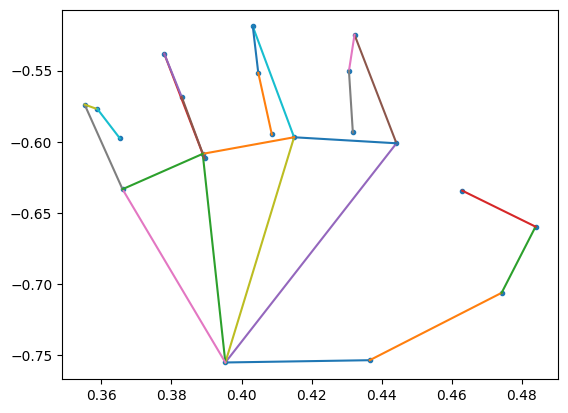

In [3]:
with open("/home/hirooka/transformer-based-sign-language-recognition/data/jslv2/skeleton_files/Subject15_jslv2/e.json") as f:
    
    keypoint_dict = json.load(f)


HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12),    # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky finger
    (5, 9), (9, 13), (13, 17)              # Palm connections
]

for timestamp in keypoint_dict.keys():
    skeleton_keypoint = np.array(keypoint_dict[timestamp])

    plt.figure()
    plt.scatter(skeleton_keypoint[:,0],-skeleton_keypoint[:,1], marker='.')

    for k1, k2 in HAND_CONNECTIONS:
        plt.plot(skeleton_keypoint[[k1,k2],0],-skeleton_keypoint[[k1,k2],1])

    plt.show()

    break

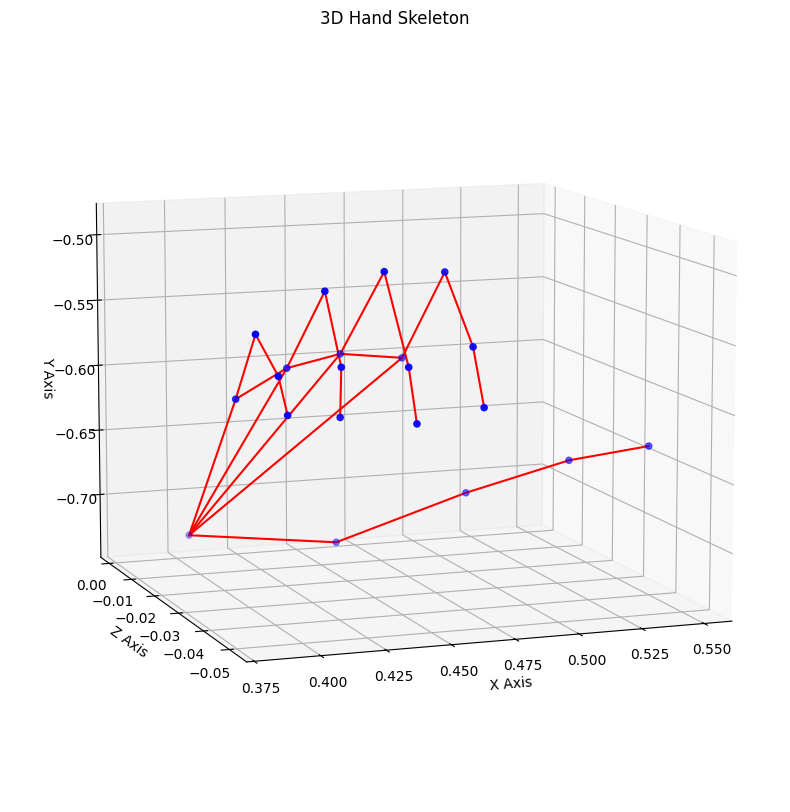

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# A list of tuples representing the pairs of keypoints that form the bones of a hand.
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12),    # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky finger
    (5, 9), (9, 13), (13, 17)              # Palm connections
]

def plot_hand_skeleton_3d(landmarks, elev=15, azim=240):
    """
    Plots the 3D hand skeleton using matplotlib.

    Args:
        landmarks (list of lists): A list of 21 keypoints, where each keypoint is a list
                                   or tuple of [x, y, z] coordinates.
    """
    if len(landmarks) != 21:
        print("Error: The number of landmarks is not 21.")
        return

    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111, projection='3d')

    # Extract x, y, and z coordinates from the landmarks
    x_coords = [p[0] for p in landmarks]
    y_coords = [-p[1] for p in landmarks]
    z_coords = [p[2] for p in landmarks]

    # Plot the keypoints
    ax.scatter(x_coords, z_coords, y_coords, c='b', marker='o')

    # Plot the connections (bones)
    for connection in HAND_CONNECTIONS:
        start_node = connection[0]
        end_node = connection[1]
        ax.plot(
            [landmarks[start_node][0], landmarks[end_node][0]],
            [landmarks[start_node][2], landmarks[end_node][2]],
            [-landmarks[start_node][1], -landmarks[end_node][1]],
            'r-'
        )

    # Set labels and title
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Z Axis')
    ax.set_zlabel('Y Axis')
    ax.set_title('3D Hand Skeleton')

    # Show the plot
    # plt.show()
    plt.savefig('../outputs/jsl_a_skeleton.svg', format='svg', bbox_inches='tight')


# Example usage: Generate some random dummy data for the 21 landmarks
# In a real application, this data would come from the MediaPipe Hand Landmarker model.

with open("../data/jslv2/skeleton_files/Subject15_jslv2/a.json") as f:
    
    keypoint_dict = json.load(f)

for timestamp in keypoint_dict.keys():
    skeleton_keypoint = np.array(keypoint_dict[timestamp])
    plot_hand_skeleton_3d(skeleton_keypoint, 10 ,250)
    break

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import json

DATA_ROOT = "../data/official_wlasl/pose_per_individual_videos"
target_files = [os.path.join(root, file) for root,dirs,files in os.walk(DATA_ROOT) for file in files if file.endswith("json")]
print(len(target_files))

1277410


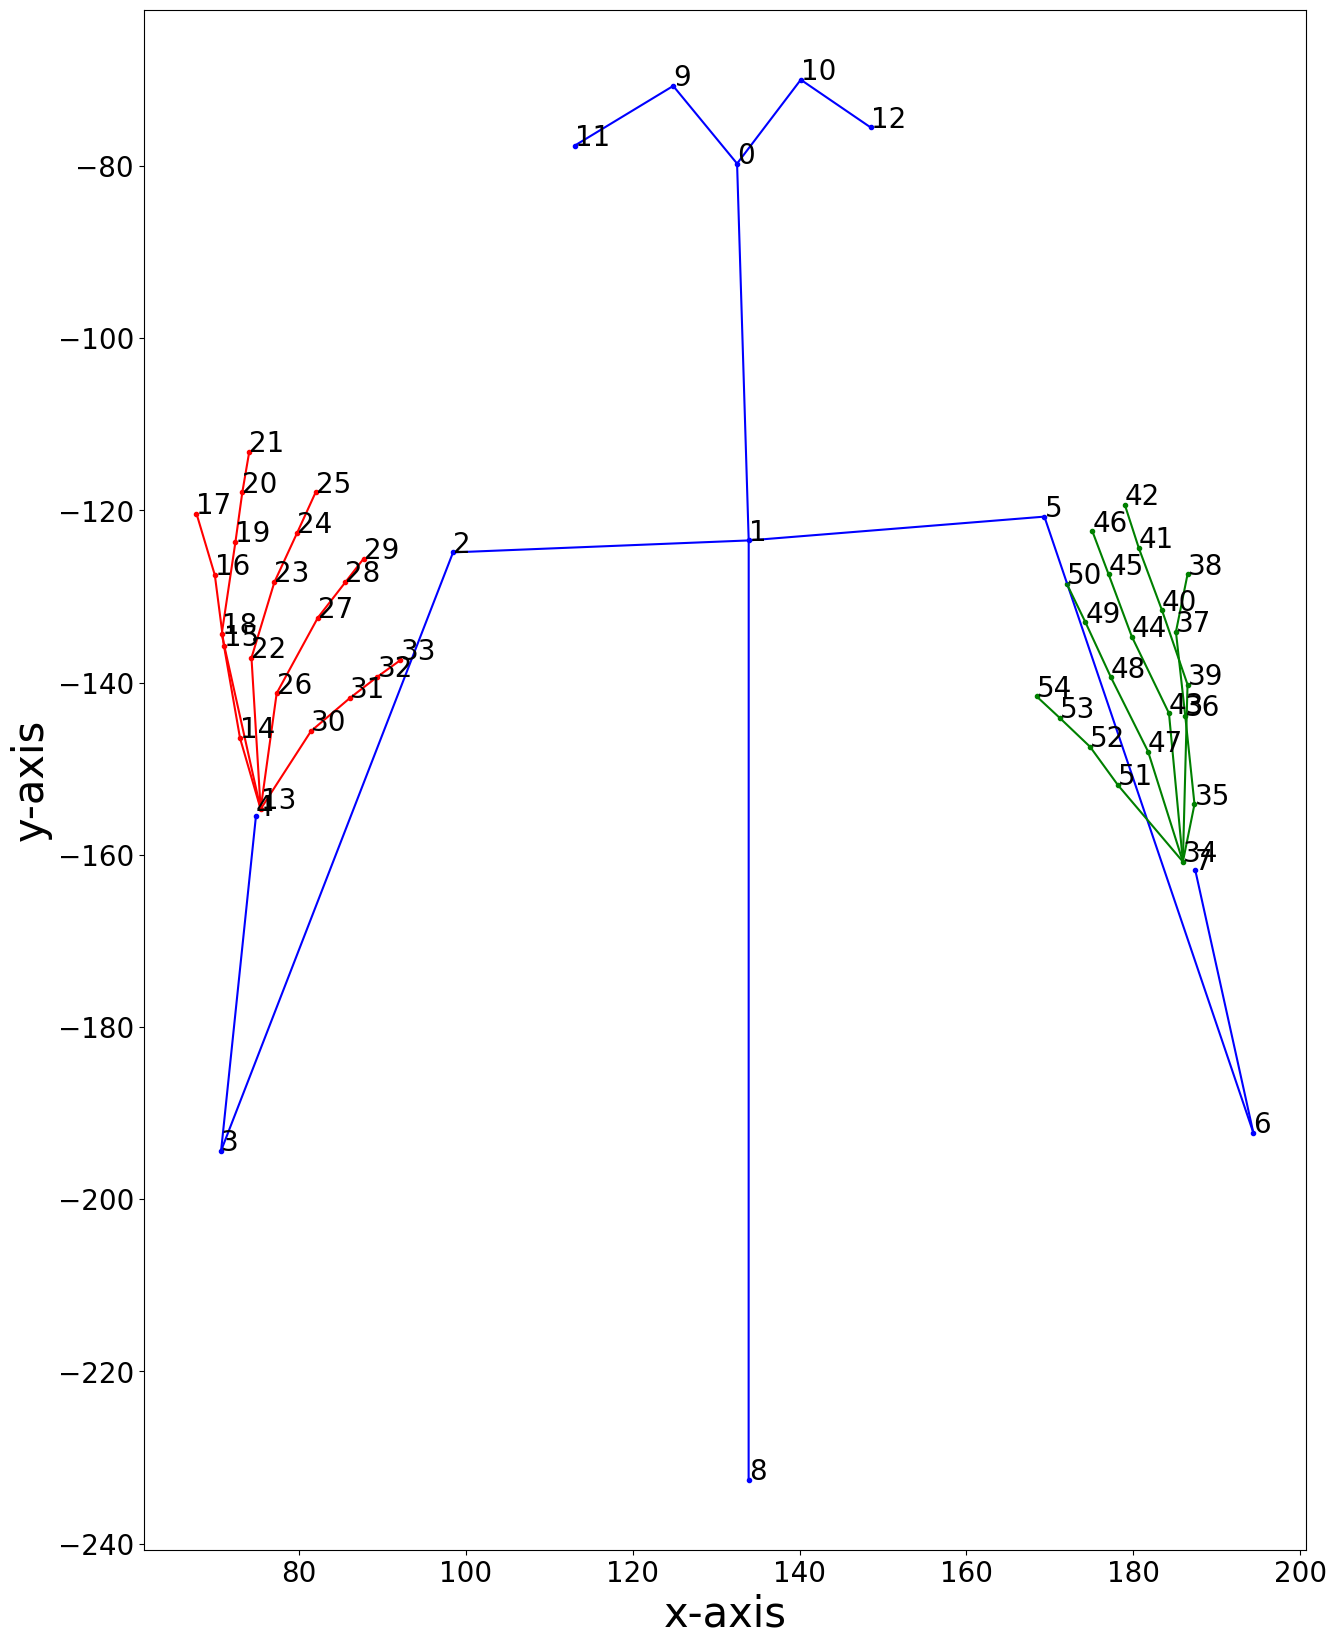

In [4]:
def func(idx:int):
    with open(target_files[idx]) as f:
        d = json.load(f)

    body_keypoint_index = list(range(9)) + list(range(15,19))
    skeleton = np.array(d["people"][0]["pose_keypoints_2d"]).reshape(-1,3)
    skeleton = skeleton[body_keypoint_index]
    hand_r = np.array(d["people"][0]["hand_right_keypoints_2d"]).reshape(-1,3)
    hand_l = np.array(d["people"][0]["hand_left_keypoints_2d"]).reshape(-1,3)


    body_bone = [
        (0,1),
        (1,2),(2,3),(3,4),
        (1,5),(5,6),(6,7),
        (1,8),
        (0,9),(9,11),
        (0,10),(10,12)
    ]

    hand_bone = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (0,9),(9,10),(10,11),(11,12),
        (0,13),(13,14),(14,15),(15,16),
        (0,17),(17,18),(18,19),(19,20)
    ]

    scale = 5
    plt.figure(figsize=(3*scale,4*scale))
    plt.plot(skeleton[:,0],-skeleton[:,1],'.',color="b")
    plt.plot(hand_l[:,0], -hand_l[:,1],'.',color="g")
    plt.plot(hand_r[:,0], -hand_r[:,1],'.',color="r")

    all_point = np.concatenate([skeleton,hand_r,hand_l])
    for i in range(len(all_point)):
        plt.text(all_point[i,0],-all_point[i,1],i,fontsize=10*2)


    for i, j in body_bone:
        plt.plot([skeleton[i,0], skeleton[j,0]],[-skeleton[i,1], -skeleton[j,1]], color="b")

    for i, j in hand_bone:
        plt.plot([hand_r[i,0], hand_r[j,0]],[-hand_r[i,1], -hand_r[j,1]], color="r")

    for i, j in hand_bone:
        plt.plot([hand_l[i,0], hand_l[j,0]],[-hand_l[i,1], -hand_l[j,1]], color="g")

    
    plt.xlabel("x-axis",fontsize=30)
    plt.ylabel("y-axis",fontsize=30)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)



    plt.savefig("../outputs/skeleton.png",bbox_inches='tight')
    # plt.savefig('../outputs/skeleton.svg', format='svg', bbox_inches='tight')


func(50)